<a href="https://colab.research.google.com/github/greeshmakrishnan00/Machine-Learning/blob/main/Breast_Cancer_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load and Inspect the Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/BREAST CANCER.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Understand the Data Types and Summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# Data Cleaning

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Visualization





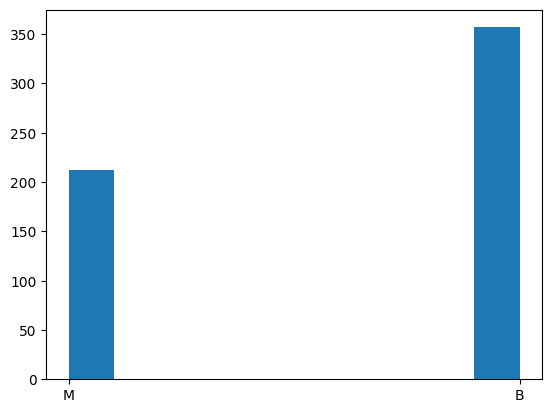

In [ ]:
plt.hist(df['diagnosis'])
plt.show()

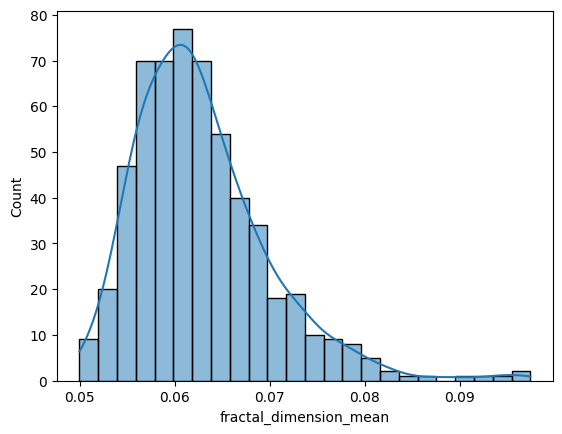

In [ ]:
sns.histplot(df["fractal_dimension_mean"],kde=True)
plt.show()

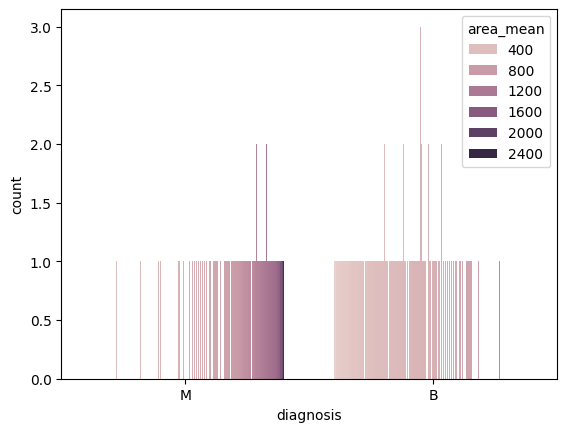

In [ ]:
sns.countplot(data=df,x="diagnosis",hue="area_mean")
plt.show()

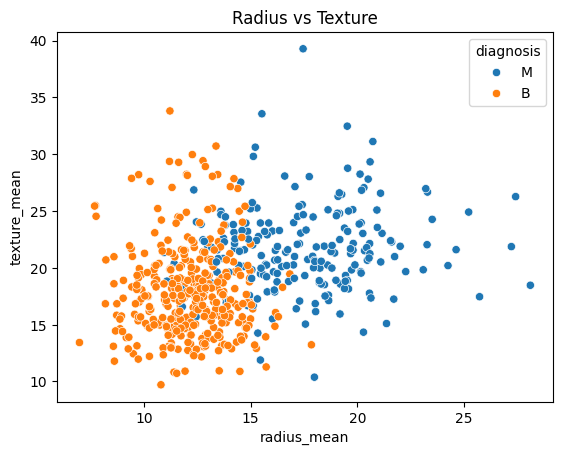

In [ ]:
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)
plt.title("Radius vs Texture")
plt.show()

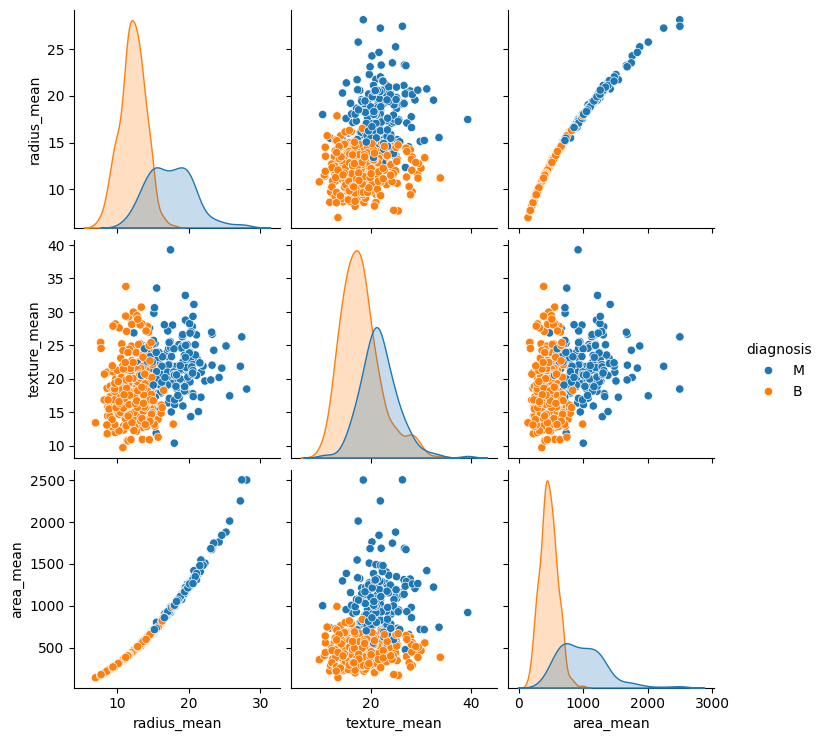

In [ ]:
sns.pairplot(df[['radius_mean','texture_mean','area_mean','diagnosis']], hue='diagnosis')
plt.show()

# Correlation analysis

In [ ]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
print(df["diagnosis"].unique())

['M' 'B']


In [ ]:
df["diagnosis"].replace(['M','B'],[0,1],inplace=True)

/tmp/ipykernel_1389/1130038873.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["diagnosis"].replace(['M','B'],[0,1],inplace=True)
/tmp/ipykernel_1389/1130038873.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["diagnosis"].replace(['M','B'],[0,1],inplace=True)


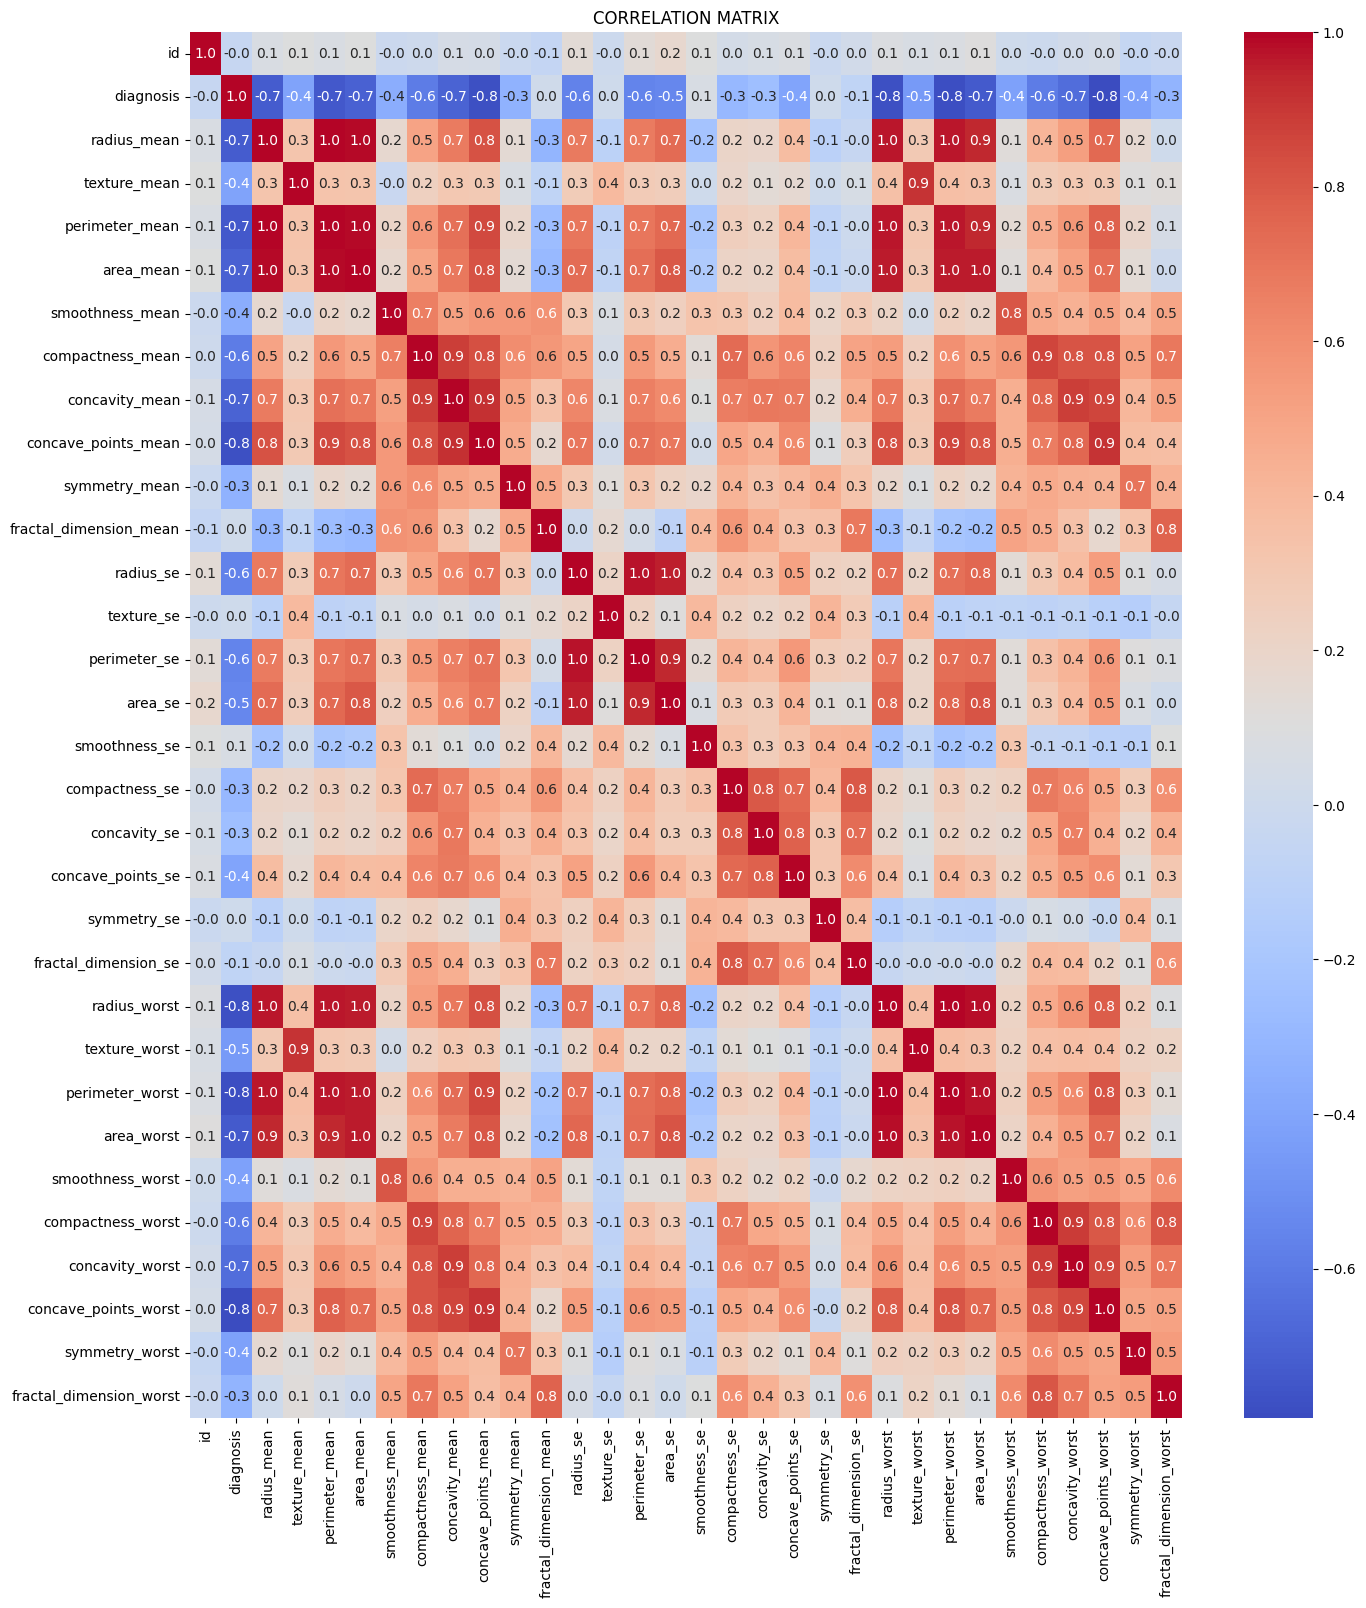

In [ ]:
corr_matrix=df.corr()
plt.figure(figsize=(16,18))
sns.heatmap(corr_matrix,annot=True,fmt="0.1f",cmap="coolwarm")
plt.title("CORRELATION MATRIX")
plt.show()

In [ ]:
df.head(1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop(["radius_mean","texture_mean","perimeter_mean","area_mean","compactness_mean","concavity_mean","concave_points_mean","compactness_worst","concavity_worst","concave_points_worst","perimeter_worst","area_worst","texture_worst","radius_se","perimeter_se","area_se"],axis=1,inplace=True)

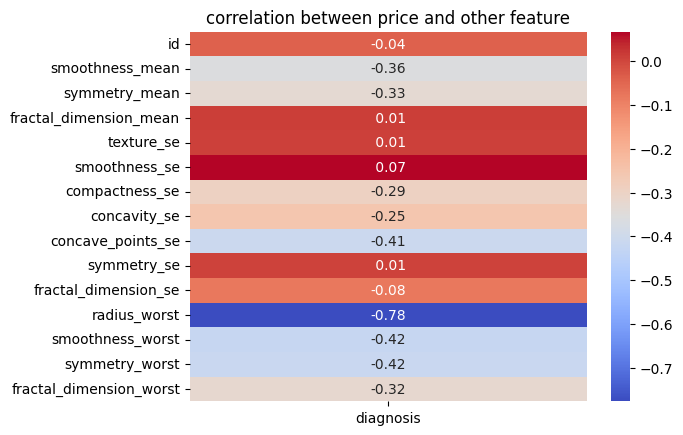

In [ ]:
from pickleshare import stat
status_corr=df.corr()["diagnosis"]
status_corr=status_corr.drop("diagnosis")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap="coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other feature")
plt.show()

In [ ]:
df.drop(["fractal_dimension_mean","texture_se","symmetry_se"],axis=1,inplace=True)

# Outlier Checking and removing

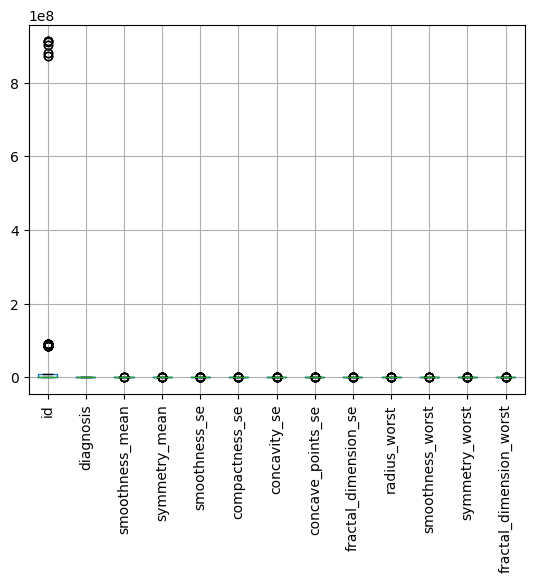

In [ ]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [ ]:
from numpy._core.defchararray import upper
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col==exclude_column:
        continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lowerbound=Q1-1.5*IQR
    upperbound=Q3+1.5*IQR
    df=df[(df[col]>=lowerbound)&(df[col]<=upperbound)]
  return df
df_cleaned=remove_outliers_iqr(df,exclude_column="diagnosis")
df=df_cleaned

In [ ]:
df.shape

(366, 13)

In [ ]:
df.head(1)

,id,diagnosis,smoothness_mean,symmetry_mean,smoothness_se,compactness_se,concavity_se,concave_points_se,fractal_dimension_se,radius_worst,smoothness_worst,symmetry_worst,fractal_dimension_worst
1,842517,0,0.08474,0.1812,0.005225,0.01308,0.0186,0.0134,0.003532,24.99,0.1238,0.275,0.08902


# Data Scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features=["id","smoothness_mean","symmetry_mean","smoothness_se","compactness_se","concavity_se","concave_points_se","fractal_dimension_se","radius_worst","smoothness_worst","symmetry_worst","fractal_dimension_worst"]
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
# use logisticRegression because our dataset is classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x= df[["id","smoothness_mean","symmetry_mean","smoothness_se","compactness_se","concavity_se","concave_points_se","fractal_dimension_se","radius_worst","smoothness_worst","symmetry_worst","fractal_dimension_worst"]]
y= df['diagnosis']  # Target variable

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

# Train a baseline logistic regression model
model= LogisticRegression()
model.fit(x_train, y_train)

# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.74


# Confusion Matrix For Accuracy

<Figure size 2000x700 with 0 Axes>

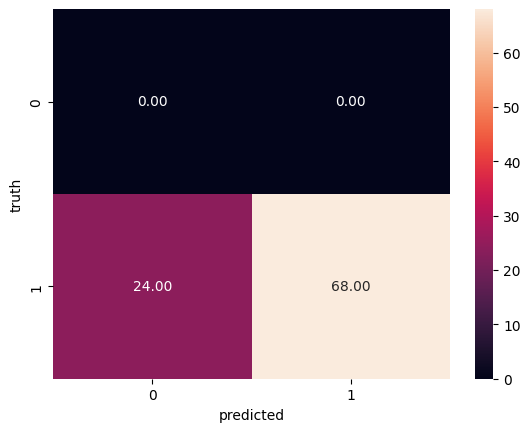

<Figure size 2000x700 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix

#get xtest predict value to get predicted values
y_predicted=model.predict(x_test)
y_predicted

#get confusion matrix
cm=confusion_matrix(y_predicted,y_test)
cm

#plot confusion matrix using heatmap
import seaborn as sn
sn.heatmap(cm,fmt=".2f",annot=True)
plt.xlabel("predicted")
plt.ylabel("truth")
plt.figure(figsize=(20,7))